In [4]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import t
import PIL
from scipy.special import erf
plt.rcParams['font.family']='serif'
import os 
from matplotlib_scalebar.scalebar import ScaleBar

Npixeles=1024
NI=1 #Número de imágenes RAW
NF=1 #Número de imágenes FF
NThr=1 #Número de imágenes contenidas dentro de cada .raw: La primera es la dada por el canal 0 y la segunda es la dada por el canal 1.
nameRAW1="../build/SiC_LUNGS_S" #PEPI2/build/SiC_LUNGS_R00_20um_NoFilter_28kV__d0.75m_a15um_p62um_step-4.2_dith23.25_1.raw
nameRAW2 = "_20um_NoFilter_28kV__d0.75m_a15um_p62um_step-4.2_dith23.25_" 
nameRAW3 = "_SiC_Poli__d0.75m_a15um_p62um_step-4.2_dith23.25_"
nameRAW4 = "../build/SiC_LUNGS_R"

nameRAW5 = "_TiC_Poli_20um_02Al_Red_1_d0.75m_a15um_p62um_step-4.2_dith23.25_"
nameRAW6="_TiC_Poli_20um_02Al_Red_2_d0.75m_a15um_p62um_step-4.2_dith23.25_"
nameRAW7="_TiC_Poli_20um_137e9_d0.75m_a15um_p62um_step-4.2_dith23.25_"
import os
if not os.path.exists("FS_Measurements_txt_Files"):
    os.makedirs("FS_Measurements_txt_Files")

In [8]:
def ImagenesR(name,Npixeles):
    I=[]
    for k in range(0,len(name),Npixeles*Npixeles):
        Im=np.zeros((Npixeles,Npixeles))
        for j in range(Npixeles):
            for i in range(Npixeles):
                Im[j,i]=name[i+Npixeles*j+k]
        I.append(Im)
    return I
def Imagenes(name,Npixeles,NI):
    D=[]
    for i in range(1,NI+1):
        Raw=np.fromfile(name+"{}.raw".format(i), dtype='float32')
        K=ImagenesR(Raw,Npixeles)
        D.append(K)
    return D
def sumar_imagenes(name1, name2,name3,name4, Npixeles):
    # Inicializar una matriz para almacenar la suma de las imágenes
    suma_imagenes = np.zeros((Npixeles, Npixeles), dtype='float32')
    
    # Iterar sobre las imágenes (de R00 a R09)
    for i in range(0,20):  # Cambiado a 10 para incluir R00 a R09
        # Construir el nombre del archivo
        one_image = f"{name1}{i:02d}{name2}.raw"
        due_image = f"{name1}{i:02d}{name3}.raw"
        tree_image = f"{name1}{i:02d}{name4}.raw"
        
        # Leer la imagen desde el archivo .raw
        Raw1 = np.fromfile(one_image, dtype='float32')
        Raw2 = np.fromfile(due_image, dtype='float32')
        Raw3 = np.fromfile(tree_image, dtype='float32')

        Raw = Raw1 + Raw2 + Raw3
        
        # Convertir la imagen en una matriz 2D
        K = ImagenesR(Raw, Npixeles)
        
        # Sumar la imagen actual a la suma acumulada
        suma_imagenes += K[0]  # Asumiendo que K[0] es la matriz 2D de la imagen
    
    return suma_imagenes
def Imagenes2(name1, name2, Npixeles, NI):    
    D = []
    for i in range(20):
        Raw = np.fromfile(name1 + "{:02d}".format(i) + name2 + "1.raw", dtype='float32')
        K = ImagenesR(Raw, Npixeles)
        D.append(K[0])  # Append the first image in the list to avoid extra dimension
    return D
def ImagenesA(name,Npixeles,NI,NThr):
    A=[]
    for i in range(NThr):
        Mean=np.zeros((Npixeles, Npixeles))
        for j in range (NI):
            Mean=Mean+name[j][i]
        A.append(Mean)
    return A
def CNR(meanS,meanB,stdB):
    CNR = (meanB - meanS)/stdB
    return CNR

RAW = Imagenes2(nameRAW1,nameRAW2,Npixeles,NI)
#RAW2 = Imagenes2(nameRAW1,nameRAW3,Npixeles,NI)
REF = Imagenes2(nameRAW4,nameRAW2,Npixeles,NI)
REF = np.array(REF)
RAW = np.array(RAW)

#RAW1 = Imagenes2(nameRAW1,nameRAW5,Npixeles,NI)
#RAW2 = Imagenes2(nameRAW1,nameRAW6,Npixeles,NI)
#RAW3 = Imagenes2(nameRAW1,nameRAW7,Npixeles,NI)
#REF1 = Imagenes2(nameRAW4,nameRAW5,Npixeles,NI)
#REF2 = Imagenes2(nameRAW4,nameRAW6,Npixeles,NI)
#REF3 = Imagenes2(nameRAW4,nameRAW7,Npixeles,NI)


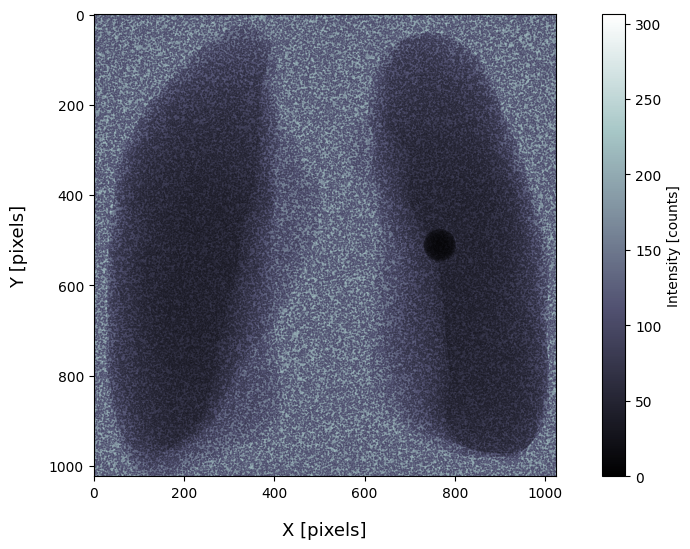

In [ ]:
RAW = []
for i in range(len(RAW1)):
    RAW.append(RAW1[i] + RAW2[i] )#+ RAW3[i])

REF = []
for i in range(len(REF1)):
    REF.append(REF1[i] + REF2[i] )#+ REF3[i])

RAW = np.array(RAW)
REF = np.array(REF)

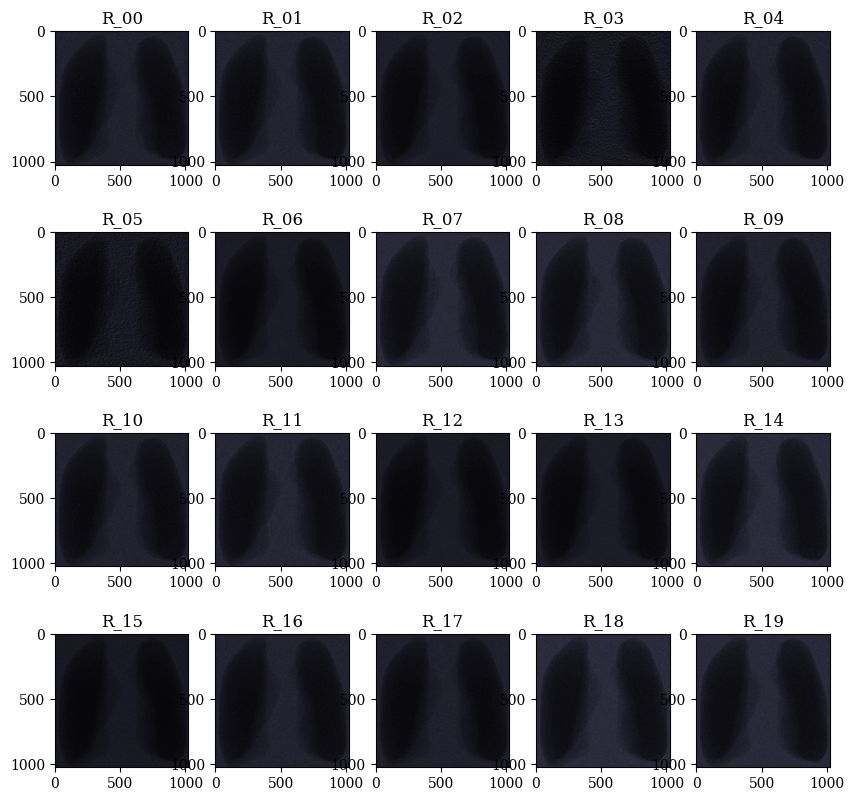

In [9]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(RAW[i]/REF[i],cmap='bone')
    plt.title(f'R_{i:02d}')

In [60]:
import UMPA
I_ref,Isamp = [],[]
FS_Size = 300
ref = REF# Establishing empty arrays to put SB-PCXI data into
sam = RAW#np.load(f"DATA_Prosesada_14.75keV/RAW_FF_14.75keV.npy")


UMPA_res2 = UMPA.match(sam, ref, 9,max_shift=10) # provide sample and reference images in input to #UMPA, 3 is the window size (user defined)
UMPA_bias2 = UMPA.match(ref, ref, 9,max_shift=10) # UMPA sometimes can output images with a #sistematic bias: you can compute this by taking UMPA result from ref Vs ref
#UMPA_res2 = UMPA.match(np.expand_dims(sam[0],axis=0), np.expand_dims(ref[0],axis=0), 4,max_shift=10) # provide sample and reference images in input to #UMPA, 3 is the window size (user defined)
#UMPA_bias2 = UMPA.match(np.expand_dims(ref[0],axis=0), np.expand_dims(ref[0],axis=0), 4,max_shift=10) 
def inverse_grad(grad_x: np.ndarray, grad_y: np.ndarray, epsilon: float = 1e-6) -> np.ndarray:
    """
    Reconstruye la fase (phi_UMPA) a partir de los gradientes (grad_x, grad_y).
    Basado en la ecuación de Poisson: ∇²ϕ = ∇·G, donde G = (grad_x, grad_y).
    """
    rows, cols = grad_x.shape
    ky, kx = np.mgrid[-rows//2:rows//2, -cols//2:cols//2]
    kx = (2 * np.pi * kx) / cols
    ky = (2 * np.pi * ky) / rows

    # Divergencia del campo de gradientes (∇·G)
    div_G = np.fft.fft2(grad_x) * 1j * kx + np.fft.fft2(grad_y) * 1j * ky

    # Resuelve la ecuación de Poisson en espacio Fourier (evita división por cero)
    kernel = kx**2 + ky**2 + epsilon
    kernel[kernel == 0] = epsilon  # Regularización
    phi_fft = div_G / kernel

    # Transformada inversa para obtener la fase reconstruida
    phi_UMPA = np.fft.ifft2(phi_fft).real
    return phi_UMPA 
phi = inverse_grad(UMPA_res2['dx'], UMPA_res2['dy'],epsilon=1e-4)
print(phi.shape)
#guardar imagenes en formato .txt
dx = UMPA_res2['dx']-UMPA_bias2['dx']
np.savetxt(f'FS_Measurements_txt_Files/dx_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', dx, fmt='%f')
dy = UMPA_res2['dy']-UMPA_bias2['dy']
np.savetxt(f'FS_Measurements_txt_Files/dy_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', dy, fmt='%f')
df = UMPA_res2['df']-UMPA_bias2['df']
T = UMPA_res2['T']
np.savetxt(f'FS_Measurements_txt_Files/T_SiC_60um_FS{FS_Size}um_21kev_2x150_75_AIR.txt', T, fmt='%f')
from scipy.ndimage import gaussian_filter
dx = gaussian_filter(dx, sigma=1)  # Aplicar filtro gaussiano para suavizar
dy = gaussian_filter(dy, sigma=1)  # Aplicar filtro gaussiano

#np.savetxt("Golden_Results/dx_TiC_90um_19k_PMMA.txt", dx)
#np.savetxt("Golden_Results/dy_TiC_90um_19k_PMMA.txt", dy)




Using 16 threads
Using 16 threads
(998, 998)


/tmp/ipykernel_3692954/2686096928.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(4,4,1)


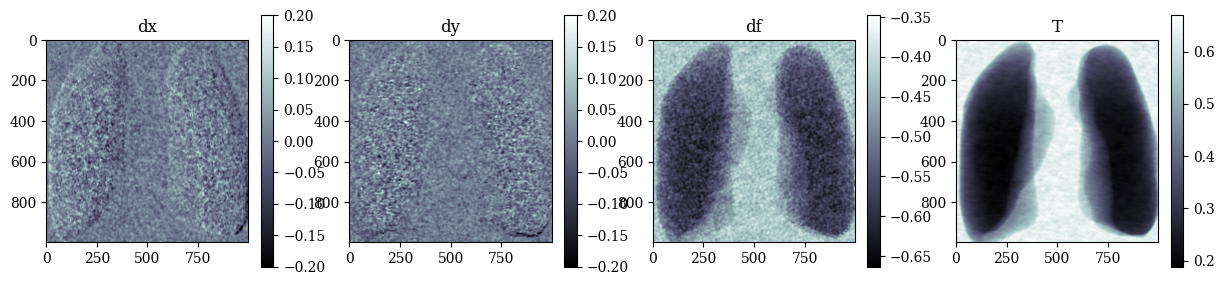

In [61]:
plt.figure(figsize=(15,15))
plt.title('UMPA results at 19kev and 1e9 events')
plt.subplot(4,4,1)
plt.imshow(dx,cmap='bone',vmin=-0.2,vmax=0.2) #here subtract bias to the result -UMPA_bias['dx']
#np.savetxt('dx_4_90.txt', UMPA_res['dx']-UMPA_bias['dx'])
plt.title('dx')
plt.colorbar()
plt.subplot(4,4,2)
plt.imshow(dy,cmap='bone',vmin=-0.2,vmax=0.2) #-UMPA_bias['dy']
plt.title('dy')
#np.savetxt('dy_4_90.txt', UMPA_res['dy']-UMPA_bias['dy'])
plt.colorbar()
plt.subplot(4,4,3)
plt.imshow(df,cmap='bone') #-UMPA_bias['T']
plt.title('df')  
plt.colorbar()
plt.subplot(4,4,4)
plt.imshow(T,cmap='bone') #-UMPA_bias['T']
plt.title('T')  
plt.colorbar()

In [47]:
from pathlib import Path

# Carpeta principal
main_folder = Path("Poli_Results_Umpa_SiC")

# Lista de focal spots
focal_spots = [ "20um"]

# Crear carpeta principal
main_folder.mkdir(exist_ok=True)

# Crear subcarpetas
for fs in focal_spots:
    (main_folder / fs).mkdir(exist_ok=True)

print("✔ Carpetas creadas correctamente")


✔ Carpetas creadas correctamente


In [62]:
focal_spot = "20"
np.savetxt(f'Poli_Results_Umpa_SiC/{focal_spot}um/dx_w9.txt', dx, fmt='%f')
np.savetxt(f'Poli_Results_Umpa_SiC/{focal_spot}um/dy_w9.txt', dy, fmt='%f')
np.savetxt(f'Poli_Results_Umpa_SiC/{focal_spot}um/df_w9.txt', df, fmt='%f')
np.savetxt(f'Poli_Results_Umpa_SiC/{focal_spot}um/T_w9.txt', T, fmt='%f')

In [63]:
size = np.shape(dx)
print(size)

(998, 998)


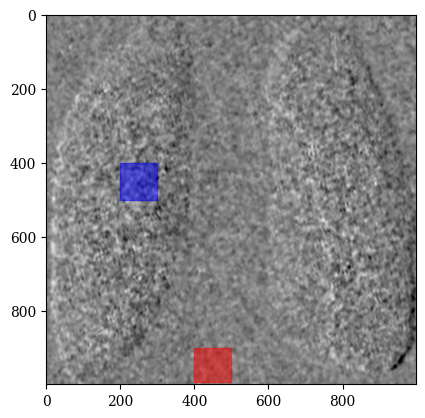

In [66]:
plt.imshow(dx,cmap='gray',vmin=-0.2,vmax=0.2) #here subtract bias to the result -UMPA_bias['dx']
plt.axhspan(900, 990,400/size[0],500/size[0], alpha=0.5, color='red')
plt.axhspan(400, 500,200/size[0],300/size[0], alpha=0.5, color='blue')

In [67]:
def SNR(image):
    signal = np.mean(image[400:500,200:300])
    noise = np.std(image[900:1000,400:500])
    SNR = signal / noise
    return SNR

In [68]:
SNR_x = SNR(dx)
SNR_y = SNR(dy)
print(SNR_x, SNR_y)

-0.24090290594225847 0.09671273939343708
